# Diversified ETF Rotation Backtest

This notebook implements a transparent weekly ETF rotation process:

`Momentum → own-trend eligibility → ranking → hysteresis/Top-N selection → inverse-volatility weights → portfolio volatility estimate → raw volatility-target exposure → momentum leverage gate → final exposure → next-session execution`

**Timing rule:** every signal uses data available at the signal session's close. Target weights and leverage state are first applied to the **next trading session's return**. Positions drift between rebalances, and transaction costs are charged when the next-session rebalance is executed.

Rank-buffer logic is intentionally explicit: eligible incumbents ranked at or above `EXIT_RANK` are retained first; remaining slots are filled by non-held ETFs whose entry rank is at or above `TOP_N`. Trend failure removes an incumbent immediately at the next execution. With hysteresis disabled, the highest-ranked `TOP_N` eligible ETFs are selected.

**Momentum leverage gate:** volatility determines desired exposure; momentum only determines whether exposure above 1.0x is permitted. To turn the gate on, every selected ETF must have all 3/6/12-month returns positive. Once on, every selected ETF must retain at least `LEVERAGE_OFF_MIN_POSITIVE` positive horizons. No selection turns it off immediately. Momentum never raises exposure.

When fewer than `TOP_N` risky ETFs are selected, the initial risky sleeve is `selected_count / TOP_N`; the remainder is cash. All ETF weights, including `CASH_ETF`, remain non-negative. When risky exposure exceeds 100%, cash is held at zero and the excess is tracked separately as financing; its cost uses the `CASH_ETF` return. The strategy never shorts an ETF.

**Optional high-volatility overlay:** after inverse-volatility weighting and portfolio volatility targeting, each selected ETF's current realized volatility is compared with its prior rolling-median volatility reference. A triggered ETF's final allocation is multiplied by `HIGH_VOL_WEIGHT_MULTIPLIER`. The reduction first lowers any financing amount; once risky exposure is below 1.0, the balance is assigned to `CASH_ETF`. The overlay never increases risk, and its adjusted target still begins on the next session.

The universe is user supplied, so results inherit the usual survivorship assumptions of that list. Correlation and benchmark regimes are diagnostics only and never alter allocations. Robustness checks vary one parameter at a time and are not an optimization or a trading recommendation.

The existing high-volatility overlay remains downstream of the leverage gate and can only reduce exposure. Parameter robustness is deferred; the primary experiment changes only leverage policy.


In [61]:
import warnings
from dataclasses import dataclass, replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:,.4f}".format


In [62]:
# -------------------- User configuration --------------------
ETF_UNIVERSE = [
    # "SPY",
    "QQQ",
    # "IWM",
    "VXUS",
    # "EEM",
    "TLT",
    # "IEF",
    # "TIP",
    "GLD",
    # "PDBC", 
    # "DBC",
    "VNQ",
]

BENCHMARK_ETF = "QQQ"
CASH_ETF = "BIL"

START_DATE = "2007-01-01"
END_DATE = None

REBALANCE_FREQUENCY = "M"

TOP_N = 2
EXIT_RANK = 5

MOMENTUM_LOOKBACKS = [63, 126, 252]
MOMENTUM_WEIGHTS = [0.50, 0.30, 0.20]

TREND_MA = 150

VOL_LOOKBACK = 20
TARGET_VOL = 0.2

USE_MOMENTUM_LEVERAGE_GATE = True
MAX_GROSS_EXPOSURE = 1.50
NORMAL_GROSS_CAP = 1.00

LEVERAGE_MOMENTUM_LOOKBACKS = [63, 126, 252]
LEVERAGE_ON_REQUIRED_POSITIVE = 3
LEVERAGE_OFF_MIN_POSITIVE = 2

# Optional high-volatility allocation adjustment.
HIGH_VOL_ADJUSTMENT_ENABLED = True
HIGH_VOL_THRESHOLD = 1.20  # current vol >= 120% of reference vol
HIGH_VOL_WEIGHT_MULTIPLIER = 0.40  # retain 70% of a triggered ETF's allocation
HIGH_VOL_REFERENCE_LOOKBACK = 252  # rolling median volatility reference

USE_EMA_SMOOTHING = True
EMA_ALPHA = 0.30

TRANSACTION_COST_BPS = 5
RISK_FREE_RATE = 0.0

In [63]:
@dataclass(frozen=True)
class BacktestConfig:
    universe: tuple
    benchmark: str
    cash: str
    start: str
    end: object
    rebalance_frequency: str
    top_n: int
    exit_rank: int
    momentum_lookbacks: tuple
    momentum_weights: tuple
    trend_ma: int
    vol_lookback: int
    target_vol: float
    use_momentum_leverage_gate: bool
    max_gross_exposure: float
    normal_gross_cap: float
    leverage_momentum_lookbacks: tuple
    leverage_on_required_positive: int
    leverage_off_min_positive: int
    high_vol_adjustment_enabled: bool
    high_vol_threshold: float
    high_vol_weight_multiplier: float
    high_vol_reference_lookback: int
    use_ema_smoothing: bool
    ema_alpha: float
    transaction_cost_bps: float
    risk_free_rate: float
    use_hysteresis: bool = True

CONFIG = BacktestConfig(
    universe=tuple(ETF_UNIVERSE),
    benchmark=BENCHMARK_ETF,
    cash=CASH_ETF,
    start=START_DATE,
    end=END_DATE,
    rebalance_frequency=REBALANCE_FREQUENCY,
    top_n=TOP_N,
    exit_rank=EXIT_RANK,
    momentum_lookbacks=tuple(MOMENTUM_LOOKBACKS),
    momentum_weights=tuple(MOMENTUM_WEIGHTS),
    trend_ma=TREND_MA,
    vol_lookback=VOL_LOOKBACK,
    target_vol=TARGET_VOL,
    use_momentum_leverage_gate=USE_MOMENTUM_LEVERAGE_GATE,
    max_gross_exposure=MAX_GROSS_EXPOSURE,
    normal_gross_cap=NORMAL_GROSS_CAP,
    leverage_momentum_lookbacks=tuple(LEVERAGE_MOMENTUM_LOOKBACKS),
    leverage_on_required_positive=LEVERAGE_ON_REQUIRED_POSITIVE,
    leverage_off_min_positive=LEVERAGE_OFF_MIN_POSITIVE,
    high_vol_adjustment_enabled=HIGH_VOL_ADJUSTMENT_ENABLED,
    high_vol_threshold=HIGH_VOL_THRESHOLD,
    high_vol_weight_multiplier=HIGH_VOL_WEIGHT_MULTIPLIER,
    high_vol_reference_lookback=HIGH_VOL_REFERENCE_LOOKBACK,
    use_ema_smoothing=USE_EMA_SMOOTHING,
    ema_alpha=EMA_ALPHA,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    risk_free_rate=RISK_FREE_RATE,
)

def validate_config(cfg):
    if len(cfg.momentum_lookbacks) != len(cfg.momentum_weights):
        raise ValueError("MOMENTUM_LOOKBACKS and MOMENTUM_WEIGHTS must have equal length.")
    if not np.isclose(sum(cfg.momentum_weights), 1.0):
        raise ValueError("MOMENTUM_WEIGHTS must sum to 1.0.")
    if cfg.top_n < 1 or cfg.exit_rank < cfg.top_n:
        raise ValueError("Require TOP_N >= 1 and EXIT_RANK >= TOP_N.")
    if not 0 < cfg.ema_alpha <= 1:
        raise ValueError("EMA_ALPHA must be in (0, 1].")
    if cfg.target_vol <= 0 or cfg.max_gross_exposure <= 0:
        raise ValueError("Volatility target and exposure cap must be positive.")
    if cfg.normal_gross_cap <= 0:
        raise ValueError("NORMAL_GROSS_CAP must be positive.")
    if len(cfg.leverage_momentum_lookbacks) != 3:
        raise ValueError("LEVERAGE_MOMENTUM_LOOKBACKS must contain three horizons.")
    horizon_count = len(cfg.leverage_momentum_lookbacks)
    if not 1 <= cfg.leverage_on_required_positive <= horizon_count:
        raise ValueError("Invalid LEVERAGE_ON_REQUIRED_POSITIVE.")
    if not 1 <= cfg.leverage_off_min_positive <= cfg.leverage_on_required_positive:
        raise ValueError("Invalid LEVERAGE_OFF_MIN_POSITIVE.")
    if cfg.high_vol_threshold <= 0:
        raise ValueError("HIGH_VOL_THRESHOLD must be positive.")
    if not 0 < cfg.high_vol_weight_multiplier <= 1:
        raise ValueError("HIGH_VOL_WEIGHT_MULTIPLIER must be in (0, 1].")
    if cfg.high_vol_reference_lookback < cfg.vol_lookback:
        raise ValueError("HIGH_VOL_REFERENCE_LOOKBACK must be at least VOL_LOOKBACK.")
    if len(cfg.universe) == 0:
        raise ValueError("ETF_UNIVERSE cannot be empty.")

validate_config(CONFIG)
CONFIG


BacktestConfig(universe=('QQQ', 'VXUS', 'TLT', 'GLD', 'VNQ'), benchmark='QQQ', cash='BIL', start='2007-01-01', end=None, rebalance_frequency='M', top_n=2, exit_rank=5, momentum_lookbacks=(63, 126, 252), momentum_weights=(0.5, 0.3, 0.2), trend_ma=150, vol_lookback=20, target_vol=0.2, use_momentum_leverage_gate=True, max_gross_exposure=1.5, normal_gross_cap=1.0, leverage_momentum_lookbacks=(63, 126, 252), leverage_on_required_positive=3, leverage_off_min_positive=2, high_vol_adjustment_enabled=True, high_vol_threshold=1.2, high_vol_weight_multiplier=0.4, high_vol_reference_lookback=252, use_ema_smoothing=True, ema_alpha=0.3, transaction_cost_bps=5, risk_free_rate=0.0, use_hysteresis=True)

In [64]:
def download_prices(cfg):
    """Download auto-adjusted Yahoo daily closes, preserving pre-inception NaNs."""
    tickers = list(dict.fromkeys([*cfg.universe, cfg.benchmark, cfg.cash]))
    raw = yf.download(
        tickers=tickers,
        start=cfg.start,
        end=cfg.end,
        interval="1d",
        auto_adjust=True,
        group_by="column",
        progress=False,
        threads=True,
    )
    if raw.empty:
        raise RuntimeError("Yahoo Finance returned no data.")

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            close = raw.xs("Close", axis=1, level=0)
        elif "Close" in raw.columns.get_level_values(1):
            close = raw.xs("Close", axis=1, level=1)
        else:
            raise KeyError("Could not locate the Close field in yfinance output.")
    else:
        if "Close" not in raw.columns:
            raise KeyError("Could not locate the Close field in yfinance output.")
        close = raw[["Close"]].rename(columns={"Close": tickers[0]})

    close = close.reindex(columns=tickers).sort_index()
    close.index = pd.to_datetime(close.index).tz_localize(None)
    close = close.loc[~close.index.duplicated(keep="last")]
    close = close.apply(pd.to_numeric, errors="coerce")
    close = close.dropna(how="all")  # Never forward-fill; pre-inception NaNs remain.

    coverage = pd.DataFrame({
        "First Valid Date": close.apply(lambda s: s.first_valid_index()),
        "Last Valid Date": close.apply(lambda s: s.last_valid_index()),
        "Observations": close.count().astype(int),
    })
    return close, coverage


def calculate_momentum(prices, cfg):
    components = {
        lookback: prices.loc[:, cfg.universe].pct_change(lookback, fill_method=None)
        for lookback in cfg.momentum_lookbacks
    }
    raw = sum(
        weight * components[lookback]
        for lookback, weight in zip(cfg.momentum_lookbacks, cfg.momentum_weights)
    )
    # adjust=False is a recursive, historical-only EMA; NaNs remain until raw momentum exists.
    smoothed = raw.ewm(alpha=cfg.ema_alpha, adjust=False, min_periods=1).mean()
    ranking = smoothed if cfg.use_ema_smoothing else raw.copy()
    return {"components": components, "momentum_score": raw,
            "smoothed_score": smoothed, "ranking_score": ranking}


def calculate_trend_filter(prices, cfg):
    universe_prices = prices.loc[:, cfg.universe]
    moving_average = universe_prices.rolling(cfg.trend_ma, min_periods=cfg.trend_ma).mean()
    eligible = universe_prices.gt(moving_average) & universe_prices.notna()
    return moving_average, eligible


def calculate_volatility(prices, cfg):
    returns = prices.loc[:, cfg.universe].pct_change(fill_method=None)
    annualized = returns.rolling(cfg.vol_lookback, min_periods=cfg.vol_lookback).std() * np.sqrt(252)
    return returns, annualized



def calculate_leverage_momentum(prices, cfg):
    """Historical-only 3/6/12-month returns and positive-horizon counts."""
    universe_prices = prices.loc[:, cfg.universe]
    horizon_returns = {
        lookback: universe_prices.pct_change(lookback, fill_method=None)
        for lookback in cfg.leverage_momentum_lookbacks
    }
    available = pd.DataFrame(True, index=universe_prices.index, columns=universe_prices.columns)
    positive_count = pd.DataFrame(0, index=universe_prices.index, columns=universe_prices.columns)
    for values in horizon_returns.values():
        available &= values.notna()
        positive_count += values.gt(0).astype(int)
    positive_count = positive_count.where(available)
    strong_momentum = positive_count.eq(len(cfg.leverage_momentum_lookbacks)) & available
    return horizon_returns, positive_count, strong_momentum


def prepare_research_data(prices, cfg):
    momentum = calculate_momentum(prices, cfg)
    moving_average, trend = calculate_trend_filter(prices, cfg)
    risky_returns, volatility = calculate_volatility(prices, cfg)
    leverage_returns, leverage_positive_count, strong_momentum = calculate_leverage_momentum(
        prices, cfg
    )
    # Compare current realized vol with a trailing median that ends one session earlier.
    # min_periods=VOL_LOOKBACK allows the reference to form without delaying the
    # strategy for an additional full reference window.
    high_vol_reference = volatility.rolling(
        cfg.high_vol_reference_lookback, min_periods=cfg.vol_lookback
    ).median().shift(1)
    high_vol_ratio = volatility.div(high_vol_reference.replace(0.0, np.nan))
    high_vol_trigger = high_vol_ratio.ge(cfg.high_vol_threshold).fillna(False)
    if not cfg.high_vol_adjustment_enabled:
        high_vol_trigger.loc[:, :] = False
    # Eligibility requires every configured horizon plus trend and volatility history.
    valid_history = (
        momentum["ranking_score"].notna()
        & volatility.notna()
        & prices.loc[:, cfg.universe].notna()
    )
    eligibility = trend & valid_history
    return {
        **momentum,
        "moving_average": moving_average,
        "trend_filter": trend,
        "eligibility": eligibility,
        "risky_returns": risky_returns,
        "realized_volatility": volatility,
        "leverage_momentum_returns": leverage_returns,
        "leverage_positive_count": leverage_positive_count,
        "strong_momentum": strong_momentum,
        "high_vol_reference": high_vol_reference,
        "high_vol_ratio": high_vol_ratio,
        "high_vol_trigger": high_vol_trigger,
    }


In [65]:
def _weekly_signal_dates(index, frequency):
    # Resampling a Series of actual sessions returns each period's last available session.
    sessions = pd.Series(index, index=index)
    return pd.DatetimeIndex(sessions.resample(frequency).last().dropna().values)


def generate_weekly_selection(research, prices, cfg):
    """Return weekly ranks and selections using close-of-signal-date information only."""
    signal_dates = _weekly_signal_dates(prices.index, cfg.rebalance_frequency)
    previous = []
    records = []

    for date in signal_dates:
        eligible_names = [
            ticker for ticker in cfg.universe
            if bool(research["eligibility"].at[date, ticker])
        ]
        score = research["ranking_score"].loc[date, eligible_names].dropna()
        ordered = score.sort_values(ascending=False, kind="mergesort")
        ranks = pd.Series(np.arange(1, len(ordered) + 1), index=ordered.index, dtype=int)

        if cfg.use_hysteresis:
            # Retained incumbents get priority; trend failures are absent from ranks.
            retained = sorted(
                [ticker for ticker in previous
                 if ticker in ranks.index and ranks[ticker] <= cfg.exit_rank],
                key=lambda ticker: ranks[ticker],
            )
            entrants = [
                ticker for ticker in ordered.index
                if ranks[ticker] <= cfg.top_n and ticker not in retained
            ]
            selected = (retained + entrants)[:cfg.top_n]
        else:
            selected = list(ordered.index[:cfg.top_n])

        previous = selected
        records.append({
            "Signal Date": date,
            "Selected": tuple(selected),
            "Ranks": ranks.to_dict(),
            "Scores": ordered.to_dict(),
        })

    return pd.DataFrame(records).set_index("Signal Date")


def apply_high_vol_adjustment(risky_weights, date, research, cfg):
    """Reduce triggered ETF weights after vol targeting; send reduction to cash."""
    adjusted = risky_weights.copy()
    if adjusted.empty or not cfg.high_vol_adjustment_enabled:
        return adjusted, tuple(), 0.0
    flags = research["high_vol_trigger"].loc[date, adjusted.index].fillna(False)
    triggered = tuple(flags.index[flags])
    if not triggered:
        return adjusted, tuple(), 0.0
    before = float(adjusted.sum())
    adjusted.loc[list(triggered)] *= cfg.high_vol_weight_multiplier
    reduction = before - float(adjusted.sum())
    return adjusted, triggered, reduction


def calculate_pre_leverage_weights(selected, date, research, cfg):
    """Preserve existing inverse-volatility weights and covariance estimate."""
    selected = list(selected)
    if not selected:
        return pd.Series(dtype=float), np.nan, np.nan
    window = research["risky_returns"].loc[:date, selected].tail(cfg.vol_lookback)
    valid = [
        ticker for ticker in selected
        if window[ticker].count() >= cfg.vol_lookback
        and np.isfinite(window[ticker].std())
        and window[ticker].std() * np.sqrt(252) > 1e-4
    ]
    if not valid:
        return pd.Series(dtype=float), np.nan, np.nan
    window = window[valid].dropna()
    if len(window) < cfg.vol_lookback:
        return pd.Series(dtype=float), np.nan, np.nan
    annual_vol = window.std(ddof=1) * np.sqrt(252)
    inverse_vol = 1.0 / annual_vol.clip(lower=1e-4)
    normalized = inverse_vol / inverse_vol.sum()
    sleeve_fraction = min(len(valid) / cfg.top_n, 1.0)
    preliminary = normalized * sleeve_fraction
    covariance = window.cov().to_numpy()
    estimated_vol = float(
        np.sqrt(preliminary.to_numpy() @ covariance @ preliminary.to_numpy()) * np.sqrt(252)
    )
    return preliminary, estimated_vol, sleeve_fraction


def apply_vol_target(selection, research, prices, cfg):
    """Stateful momentum gate evaluated at signal close; execution remains next-session."""
    columns = list(dict.fromkeys([*cfg.universe, cfg.cash]))
    targets = pd.DataFrame(0.0, index=selection.index, columns=columns)
    diagnostics = []
    leverage_state = False
    tolerance = 1e-6

    for date, row in selection.iterrows():
        preliminary, estimated_vol, sleeve = calculate_pre_leverage_weights(
            row["Selected"], date, research, cfg
        )
        selected = list(preliminary.index)
        counts = research["leverage_positive_count"].loc[date, selected].dropna().astype(int)
        strong = research["strong_momentum"].loc[date, selected].fillna(False)
        pre_leverage_total = float(preliminary.sum()) if len(preliminary) else 0.0
        strong_momentum_weight = (
            float(preliminary.loc[strong.index[strong]].sum()) / pre_leverage_total
            if pre_leverage_total > 1e-12 else 0.0
        )

        if not selected:
            leverage_state = False
        elif cfg.use_momentum_leverage_gate:
            if leverage_state:
                leverage_state = bool(
                    len(counts) == len(selected)
                    and counts.ge(cfg.leverage_off_min_positive).all()
                )
            else:
                leverage_state = bool(
                    strong_momentum_weight >= 1.0 - tolerance
                    and len(counts) == len(selected)
                    and counts.ge(cfg.leverage_on_required_positive).all()
                )
        else:
            leverage_state = False

        raw_vol_scalar = (
            cfg.target_vol / estimated_vol
            if np.isfinite(estimated_vol) and estimated_vol > 1e-8 else 0.0
        )
        raw_vol_scalar = max(float(raw_vol_scalar), 0.0)
        if cfg.use_momentum_leverage_gate:
            current_gross_cap = (
                cfg.max_gross_exposure if leverage_state
                else min(cfg.normal_gross_cap, cfg.max_gross_exposure)
            )
        else:
            current_gross_cap = cfg.max_gross_exposure
        final_vol_scalar = min(raw_vol_scalar, current_gross_cap)

        risky = preliminary * final_vol_scalar
        risky, high_vol_etfs, high_vol_reduction = apply_high_vol_adjustment(
            risky, date, research, cfg
        )
        if len(risky):
            targets.loc[date, risky.index] = risky
        risky_exposure = float(risky.sum()) if len(risky) else 0.0
        cash_weight = max(1.0 - risky_exposure, 0.0)
        targets.loc[date, cfg.cash] = cash_weight

        corr_window = research["risky_returns"].loc[:date, selected].tail(cfg.vol_lookback)
        corr = corr_window.corr() if len(selected) >= 2 else pd.DataFrame()
        if len(selected) >= 2:
            upper = corr.to_numpy()[np.triu_indices(len(corr), k=1)]
            avg_corr = float(np.nanmean(upper)) if np.isfinite(upper).any() else np.nan
            max_corr = float(np.nanmax(upper)) if np.isfinite(upper).any() else np.nan
        else:
            avg_corr = max_corr = np.nan

        diagnostics.append({
            "Date": date,
            "Raw_Vol_Scalar": raw_vol_scalar,
            "Final_Vol_Scalar": final_vol_scalar,
            "Momentum_Leverage_State": bool(leverage_state),
            "Strong_Momentum_Weight": strong_momentum_weight,
            "Current_Gross_Cap": current_gross_cap,
            "Final_Gross_Exposure": risky_exposure,
            "Cash_Weight": cash_weight,
            "Leverage_Amount": max(risky_exposure - 1.0, 0.0),
            "Number_Selected": len(selected),
            "Positive_Momentum_Horizon_Counts": counts.to_dict(),
            "Selected_ETFs": tuple(selected),
            "Estimated Portfolio Vol": estimated_vol,
            "Initial Risky Sleeve": sleeve,
            "High-Vol ETFs": high_vol_etfs,
            "High-Vol Weight Reduction": high_vol_reduction,
            "Average Pairwise Correlation": avg_corr,
            "Maximum Pairwise Correlation": max_corr,
        })
    diagnostic_frame = pd.DataFrame(diagnostics).set_index("Date")
    diagnostic_frame.index.name = "Date"
    return targets, diagnostic_frame


In [66]:
def _map_to_next_session(frame, trading_index):
    execution = {}
    for signal_date, row in frame.iterrows():
        position = trading_index.searchsorted(signal_date, side="right")
        if position < len(trading_index):
            execution[trading_index[position]] = row
    return pd.DataFrame(execution).T.sort_index() if execution else pd.DataFrame(columns=frame.columns)


def _execution_timing_audit(signal_index, trading_index):
    records = []
    for signal_date in signal_index:
        position = trading_index.searchsorted(signal_date, side="right")
        if position < len(trading_index):
            records.append({"Signal Date": signal_date, "Execution Date": trading_index[position]})
    audit = pd.DataFrame(records)
    if not audit.empty:
        assert audit["Execution Date"].gt(audit["Signal Date"]).all()
    return audit


def run_backtest(prices, cfg, research=None):
    validate_config(cfg)
    research = prepare_research_data(prices, cfg) if research is None else research
    selection = generate_weekly_selection(research, prices, cfg)
    signal_targets, signal_diagnostics = apply_vol_target(selection, research, prices, cfg)
    execution_targets = _map_to_next_session(signal_targets, prices.index)
    execution_diagnostics = _map_to_next_session(signal_diagnostics, prices.index)
    timing_audit = _execution_timing_audit(signal_targets.index, prices.index)

    assets = list(signal_targets.columns)
    asset_returns = prices[assets].pct_change(fill_method=None)
    active_weights = pd.DataFrame(np.nan, index=prices.index, columns=assets)
    strategy_returns = pd.Series(np.nan, index=prices.index, name="Rotation Strategy")
    turnover = pd.Series(0.0, index=prices.index, name="Turnover")
    costs = pd.Series(0.0, index=prices.index, name="Transaction Costs")
    financing_weight = pd.Series(np.nan, index=prices.index, name="Financing Weight")
    current = pd.Series(0.0, index=assets)
    current[cfg.cash] = 1.0
    started = False
    if signal_targets.lt(-1e-12).any().any():
        raise AssertionError("Long-only strategy generated a negative ETF target.")

    for date in prices.index:
        if date in execution_targets.index:
            target = execution_targets.loc[date].astype(float)
            current_financing = max(float(current[list(cfg.universe)].sum()) - 1.0, 0.0)
            target_financing = max(float(target[list(cfg.universe)].sum()) - 1.0, 0.0)
            turnover.at[date] = 0.5 * (
                float((target - current).abs().sum())
                + abs(target_financing - current_financing)
            )
            costs.at[date] = turnover.at[date] * cfg.transaction_cost_bps / 10_000.0
            current, started = target.copy(), True
        if not started:
            continue
        day_returns = asset_returns.loc[date]
        financing = max(float(current[list(cfg.universe)].sum()) - 1.0, 0.0)
        required = current.abs() > 1e-12
        if financing > 1e-12:
            required.loc[cfg.cash] = True
        if day_returns[required].isna().any():
            continue
        active_weights.loc[date] = current
        financing_weight.at[date] = financing
        asset_return = float((current * day_returns.fillna(0.0)).sum())
        financing_cost = financing * float(day_returns[cfg.cash])
        gross_return = asset_return - financing_cost
        strategy_returns.at[date] = gross_return - costs.at[date]
        if 1.0 + gross_return > 1e-12:
            current = current * (1.0 + day_returns.fillna(0.0)) / (1.0 + gross_return)

    risky_columns = list(cfg.universe)
    gross_exposure = active_weights[risky_columns].clip(lower=0).sum(axis=1, min_count=1)
    cash_weight = active_weights[cfg.cash].copy()
    leverage_amount = (gross_exposure - 1.0).clip(lower=0.0)
    risky_count = (active_weights[risky_columns].abs() > 1e-10).sum(axis=1)
    risky_count = risky_count.where(active_weights.notna().any(axis=1))
    daily_diagnostics = execution_diagnostics.reindex(prices.index).ffill()
    first_execution = execution_targets.index.min() if len(execution_targets) else None
    if first_execution is not None:
        daily_diagnostics.loc[daily_diagnostics.index < first_execution] = np.nan
    leverage_state_daily = daily_diagnostics["Momentum_Leverage_State"].fillna(False).astype(bool)
    correlation_daily = daily_diagnostics["Average Pairwise Correlation"].astype(float)
    leverage_diagnostics = signal_diagnostics[[
        "Raw_Vol_Scalar", "Momentum_Leverage_State", "Strong_Momentum_Weight",
        "Current_Gross_Cap", "Final_Gross_Exposure", "Leverage_Amount",
        "Number_Selected", "Positive_Momentum_Horizon_Counts",
    ]].copy()
    leverage_diagnostics.insert(0, "Date", leverage_diagnostics.index)

    return {
        "config": cfg, "research": research, "selection": selection,
        "signal_targets": signal_targets, "execution_targets": execution_targets,
        "signal_diagnostics": signal_diagnostics,
        "leverage_diagnostics": leverage_diagnostics,
        "execution_diagnostics": execution_diagnostics,
        "daily_diagnostics": daily_diagnostics, "timing_audit": timing_audit,
        "active_weights": active_weights, "returns": strategy_returns,
        "turnover": turnover, "costs": costs, "gross_exposure": gross_exposure,
        "cash_weight": cash_weight, "leverage_amount": leverage_amount,
        "financing_weight": financing_weight,
        "leverage_state_daily": leverage_state_daily, "risky_count": risky_count,
        "correlation_daily": correlation_daily,
    }


In [67]:
def calculate_metrics(returns, risk_free_rate=0.0):
    returns = pd.Series(returns).dropna()
    if returns.empty:
        return {key: np.nan for key in [
            "CAGR", "Annualized Volatility", "Sharpe", "Sortino",
            "Maximum Drawdown", "Calmar", "Total Return"
        ]}
    growth = (1.0 + returns).cumprod()
    years = len(returns) / 252.0
    total_return = float(growth.iloc[-1] - 1.0)
    cagr = float(growth.iloc[-1] ** (1.0 / years) - 1.0) if years > 0 else np.nan
    volatility = float(returns.std(ddof=1) * np.sqrt(252))
    excess = returns - risk_free_rate / 252.0
    sharpe = float(excess.mean() / returns.std(ddof=1) * np.sqrt(252)) if returns.std(ddof=1) > 0 else np.nan
    downside = np.sqrt(np.mean(np.minimum(excess, 0.0) ** 2)) * np.sqrt(252)
    sortino = float(excess.mean() * 252 / downside) if downside > 0 else np.nan
    drawdown = growth / growth.cummax() - 1.0
    max_drawdown = float(drawdown.min())
    calmar = cagr / abs(max_drawdown) if max_drawdown < 0 else np.nan
    return {
        "CAGR": cagr,
        "Annualized Volatility": volatility,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Maximum Drawdown": max_drawdown,
        "Calmar": calmar,
        "Total Return": total_return,
    }


def align_strategy_and_benchmark(result, prices):
    strategy = result["returns"].dropna()
    benchmark = prices[result["config"].benchmark].pct_change(fill_method=None)
    common = pd.concat(
        [strategy, benchmark.rename("Benchmark Buy & Hold")], axis=1
    ).dropna()
    common.columns = ["Rotation Strategy", "Benchmark Buy & Hold"]
    return common


def performance_comparison(result, prices):
    cfg = result["config"]
    common = align_strategy_and_benchmark(result, prices)
    table = pd.DataFrame({
        name: calculate_metrics(common[name], cfg.risk_free_rate)
        for name in common.columns
    }).T
    years = len(common) / 252.0
    strategy_mask = common.index
    table.loc["Rotation Strategy", "Average Gross Exposure"] = result["gross_exposure"].reindex(strategy_mask).mean()
    table.loc["Rotation Strategy", "Maximum Gross Exposure"] = result["gross_exposure"].reindex(strategy_mask).max()
    table.loc["Rotation Strategy", "Average Risky ETFs Held"] = result["risky_count"].reindex(strategy_mask).mean()
    table.loc["Rotation Strategy", "Time 100% Cash"] = (
        result["gross_exposure"].reindex(strategy_mask).fillna(0).abs() < 1e-10
    ).mean()
    table.loc["Rotation Strategy", "Total Turnover"] = result["turnover"].reindex(strategy_mask).sum()
    table.loc["Rotation Strategy", "Annual Turnover"] = table.loc["Rotation Strategy", "Total Turnover"] / years
    table.loc["Rotation Strategy", "Cumulative Transaction Costs"] = result["costs"].reindex(strategy_mask).sum()
    return table, common


def drawdown_series(returns):
    growth = (1.0 + returns).cumprod()
    return growth / growth.cummax() - 1.0


def _true_run_lengths(state):
    state = pd.Series(state).fillna(False).astype(bool)
    groups = state.ne(state.shift(fill_value=False)).cumsum()
    summary = state.groupby(groups).agg(["first", "size"])
    return summary.loc[summary["first"], "size"]


def calculate_leverage_statistics(result, index=None):
    index = result["returns"].dropna().index if index is None else pd.Index(index)
    exposure = result["gross_exposure"].reindex(index).dropna()
    state = result["leverage_state_daily"].reindex(exposure.index).fillna(False).astype(bool)
    leveraged = exposure.gt(1.0 + 1e-6)
    durations = _true_run_lengths(leveraged)
    return pd.Series({
        "Average Gross Exposure": exposure.mean(),
        "Median Gross Exposure": exposure.median(),
        "Maximum Gross Exposure": exposure.max(),
        "Time Exposure > 1x": exposure.gt(1.0 + 1e-6).mean(),
        "Time Exposure = 1x": exposure.sub(1.0).abs().le(1e-6).mean(),
        "Time Exposure < 1x": exposure.lt(1.0 - 1e-6).mean(),
        "Average Exposure While Gate Enabled": exposure[state].mean() if state.any() else np.nan,
        "Leverage Activation Events": int((leveraged & ~leveraged.shift(fill_value=False)).sum()),
        "Average Leveraged-Period Duration (sessions)": durations.mean() if len(durations) else 0.0,
        "Maximum Leveraged-Period Duration (sessions)": durations.max() if len(durations) else 0,
        "Momentum Gate Activation Events": int((state & ~state.shift(fill_value=False)).sum()),
    })


def leverage_period_performance(result, index=None):
    returns = result["returns"].dropna()
    if index is not None:
        returns = returns.reindex(index).dropna()
    exposure = result["gross_exposure"].reindex(returns.index)
    rows = {}
    for label, mask in {"Leveraged periods (>1x)": exposure.gt(1.0 + 1e-6),
                        "Non-leveraged periods (<=1x)": exposure.le(1.0 + 1e-6)}.items():
        values = returns[mask.fillna(False)]
        metrics = calculate_metrics(values, result["config"].risk_free_rate)
        rows[label] = {"Total Return": metrics["Total Return"],
                       "Annualized Return": values.mean() * 252 if len(values) else np.nan,
                       "Annualized Volatility": metrics["Annualized Volatility"],
                       "Sharpe": metrics["Sharpe"], "Observations": len(values)}
    return pd.DataFrame(rows).T


def largest_drawdown_diagnostics(result, top_n=10):
    returns = result["returns"].dropna()
    if returns.empty:
        return pd.DataFrame()
    drawdown = drawdown_series(returns)
    exposure = result["gross_exposure"].reindex(returns.index)
    state = result["leverage_state_daily"].reindex(returns.index).fillna(False).astype(bool)
    underwater, episodes, start = drawdown.lt(0), [], None
    for i, date in enumerate(drawdown.index):
        if underwater.iloc[i] and start is None:
            start = date
        recovered = start is not None and not underwater.iloc[i]
        last = i == len(drawdown) - 1
        if recovered or (start is not None and last):
            end = date if recovered else drawdown.index[-1]
            episode = drawdown.loc[start:end]
            episodes.append({
                "Drawdown Start": start, "Drawdown Trough": episode.idxmin(),
                "Recovery Date": date if recovered else pd.NaT,
                "Maximum Drawdown": float(episode.min()),
                "Leverage >1x at Start": bool(exposure.loc[start] > 1.0 + 1e-6),
                "Maximum Exposure During Drawdown": float(exposure.loc[start:end].max()),
                "Momentum Leverage State at Start": bool(state.loc[start]),
            })
            start = None
    return (pd.DataFrame(episodes).sort_values("Maximum Drawdown").head(top_n).reset_index(drop=True)
            if episodes else pd.DataFrame())


In [68]:
prices, data_coverage = download_prices(CONFIG)

print("Yahoo Finance adjusted-close coverage (no pre-inception forward fill):")
display(data_coverage)

missing = data_coverage.index[data_coverage["Observations"].eq(0)].tolist()
if missing:
    raise RuntimeError(f"No Yahoo price observations for: {missing}")

research = prepare_research_data(prices, CONFIG)
full_result = run_backtest(prices, CONFIG, research=research)
performance_table, common_returns = performance_comparison(full_result, prices)
leverage_statistics = calculate_leverage_statistics(full_result, common_returns.index)
leverage_period_table = leverage_period_performance(full_result, common_returns.index)
largest_drawdowns = largest_drawdown_diagnostics(full_result, top_n=10)

print(
    f"Common backtest period: {common_returns.index.min().date()} to "
    f"{common_returns.index.max().date()} ({len(common_returns):,} sessions)"
)
display(performance_table.style.format({
    "CAGR": "{:.2%}", "Annualized Volatility": "{:.2%}", "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}", "Maximum Drawdown": "{:.2%}", "Calmar": "{:.2f}",
    "Total Return": "{:.2%}", "Average Gross Exposure": "{:.2%}",
    "Maximum Gross Exposure": "{:.2%}", "Average Risky ETFs Held": "{:.2f}",
    "Time 100% Cash": "{:.2%}", "Total Turnover": "{:.2f}x",
    "Annual Turnover": "{:.2%}",
    "Cumulative Transaction Costs": "{:.2%}",
}))

print("Leverage statistics:")
display(leverage_statistics.to_frame("Value"))
display(leverage_period_table)
display(full_result["leverage_diagnostics"].tail(12))


Yahoo Finance adjusted-close coverage (no pre-inception forward fill):


,First Valid Date,Last Valid Date,Observations
Ticker,,,
QQQ,2007-01-03,2026-09-25,4964
VXUS,2011-01-28,2026-09-25,3938
TLT,2007-01-03,2026-09-25,4964
GLD,2007-01-03,2026-09-25,4964
VNQ,2007-01-03,2026-09-25,4964
BIL,2007-05-30,2026-09-25,4863


Common backtest period: 2007-05-31 to 2026-09-25 (4,862 sessions)


,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,Calmar,Total Return,Average Gross Exposure,Maximum Gross Exposure,Average Risky ETFs Held,Time 100% Cash,Total Turnover,Annual Turnover,Cumulative Transaction Costs
Rotation Strategy,17.00%,14.90%,1.13,1.60,-16.82%,1.01,1967.69%,106.66%,157.62%,1.79,7.40%,91.40x,473.73%,4.57%
Benchmark Buy & Hold,16.30%,22.34%,0.79,1.12,-53.40%,0.31,1742.56%,nan%,nan%,nan,nan%,nanx,nan%,nan%


Leverage statistics:


,Value
Average Gross Exposure,1.0666
Median Gross Exposure,1.1411
Maximum Gross Exposure,1.5762
Time Exposure > 1x,0.6123
Time Exposure = 1x,0.0817
Time Exposure < 1x,0.3060
Average Exposure While Gate Enabled,1.1868
Leverage Activation Events,24.0000
Average Leveraged-Period Duration (sessions),124.0417
Maximum Leveraged-Period Duration (sessions),402.0000


,Total Return,Annualized Return,Annualized Volatility,Sharpe,Observations
Leveraged periods (>1x),12.6596,0.2368,0.1751,1.3519,"2,977.0000"
Non-leveraged periods (<=1x),0.5137,0.0598,0.0936,0.6390,"1,885.0000"


,Date,Raw_Vol_Scalar,Momentum_Leverage_State,Strong_Momentum_Weight,Current_Gross_Cap,Final_Gross_Exposure,Leverage_Amount,Number_Selected,Positive_Momentum_Horizon_Counts
Date,,,,,,,,,
2025-10-31,2025-10-31,1.2414,True,1.0000,1.5000,1.0377,0.0377,2,"{'GLD': 3, 'VXUS': 3}"
2025-11-28,2025-11-28,1.4560,True,1.0000,1.5000,1.0884,0.0884,2,"{'GLD': 3, 'VXUS': 3}"
2025-12-31,2025-12-31,2.2057,True,1.0000,1.5000,1.2473,0.2473,2,"{'GLD': 3, 'VXUS': 3}"
2026-01-30,2026-01-30,1.1475,True,1.0000,1.5000,0.9957,0.0000,2,"{'GLD': 3, 'VXUS': 3}"
2026-02-27,2026-02-27,0.9835,True,1.0000,1.5000,0.3934,0.0000,2,"{'GLD': 3, 'VXUS': 3}"
2026-03-31,2026-03-31,0.7380,True,1.0000,1.5000,0.2952,0.0000,2,"{'GLD': 3, 'VXUS': 3}"
2026-04-30,2026-04-30,1.0494,True,0.5015,1.5000,0.7336,0.0000,2,"{'VXUS': 3, 'GLD': 2}"
2026-05-29,2026-05-29,1.1601,True,1.0000,1.5000,0.8478,0.0000,2,"{'VXUS': 3, 'QQQ': 3}"
2026-06-30,2026-06-30,0.7192,True,1.0000,1.5000,0.2877,0.0000,2,"{'QQQ': 3, 'VXUS': 3}"


## Research and execution audit trail

This section retains ranking momentum, leverage horizon counts, signal-close leverage decisions, and next-session execution dates. The assertion proves that every target and leverage state begins after its signal close.


In [69]:
AUDIT_START = full_result["selection"].index.max() - pd.Timedelta(days=35)
AUDIT_END = full_result["selection"].index.max()

audit = full_result["selection"].loc[AUDIT_START:AUDIT_END].copy()
audit = audit.join(full_result["leverage_diagnostics"], how="left")
audit["Execution Date"] = [
    prices.index[prices.index.searchsorted(date, side="right")]
    if prices.index.searchsorted(date, side="right") < len(prices.index) else pd.NaT
    for date in audit.index
]
display(audit)
display(pd.concat({
    "Raw Momentum": research["momentum_score"].loc[AUDIT_START:AUDIT_END],
    "EMA Momentum": research["smoothed_score"].loc[AUDIT_START:AUDIT_END],
    "Ranking Score": research["ranking_score"].loc[AUDIT_START:AUDIT_END],
    "Positive Leverage Horizons": research["leverage_positive_count"].loc[AUDIT_START:AUDIT_END],
}, axis=1).tail(10))

timing_audit = full_result["timing_audit"]
assert not timing_audit.empty
assert timing_audit["Execution Date"].gt(timing_audit["Signal Date"]).all()
print("Look-ahead assertion passed: leverage state and targets execute strictly after signal close.")
display(timing_audit.tail(12))


,Selected,Ranks,Scores,Date,Raw_Vol_Scalar,Momentum_Leverage_State,Strong_Momentum_Weight,Current_Gross_Cap,Final_Gross_Exposure,Leverage_Amount,Number_Selected,Positive_Momentum_Horizon_Counts,Execution Date
Signal Date,,,,,,,,,,,,,
2026-08-31,"(QQQ, VXUS)","{'QQQ': 1, 'VXUS': 2, 'VNQ': 3}","{'QQQ': 0.09340940674480838, 'VXUS': 0.0815922...",2026-08-31,1.5283,True,0.6040,1.5000,1.5000,0.5000,2,"{'QQQ': 2, 'VXUS': 3}",2026-09-01
2026-09-25,"(QQQ, VXUS)","{'QQQ': 1, 'VXUS': 2}","{'QQQ': 0.1451574078108186, 'VXUS': 0.09197529...",2026-09-25,1.3692,True,1.0000,1.5000,1.3692,0.3692,2,"{'QQQ': 3, 'VXUS': 3}",NaT


Raw Momentum                                EMA Momentum         \
Ticker              QQQ   VXUS     TLT     GLD     VNQ          QQQ   VXUS   
Date                                                                         
2026-09-14       0.0953 0.0841 -0.0482 -0.0014  0.0063       0.1022 0.0972   
2026-09-15       0.0682 0.0663 -0.0519 -0.0112  0.0056       0.0920 0.0879   
2026-09-16       0.0739 0.0616 -0.0538 -0.0203 -0.0032       0.0866 0.0800   
2026-09-17       0.1028 0.0836 -0.0428  0.0159  0.0184       0.0915 0.0811   
2026-09-18       0.0992 0.0725 -0.0526  0.0385  0.0104       0.0938 0.0785   
2026-09-21       0.1369 0.0973 -0.0350  0.0444  0.0245       0.1067 0.0842   
2026-09-22       0.1573 0.1096 -0.0377  0.0631  0.0149       0.1219 0.0918   
2026-09-23       0.1510 0.0919 -0.0573  0.0562  0.0020       0.1306 0.0918   
2026-09-24       0.1458 0.0786 -0.0734  0.0385 -0.0028       0.1352 0.0878   
2026-09-25       0.1685 0.1016 -0.0715  0.0502 -0.0094       0.1452 0.0920   

                                  Ranking Score                                \
Ticker         TLT     GLD    VNQ           QQQ   VXUS     TLT     GLD    VNQ   
Date                                                                            
2026-09-14 -0.0431  0.0072 0.0183        0.1022 0.0972 -0.0431  0.0072 0.0183   
2026-09-15 -0.0458  0.0017 0.0145        0.0920 0.0879 -0.0458  0.0017 0.0145   
2026-09-16 -0.0482 -0.0049 0.0092        0.0866 0.0800 -0.0482 -0.0049 0.0092   
2026-09-17 -0.0466  0.0013 0.0119        0.0915 0.0811 -0.0466  0.0013 0.0119   
2026-09-18 -0.0484  0.0125 0.0115        0.0938 0.0785 -0.0484  0.0125 0.0115   
2026-09-21 -0.0443  0.0221 0.0154        0.1067 0.0842 -0.0443  0.0221 0.0154   
2026-09-22 -0.0424  0.0344 0.0152        0.1219 0.0918 -0.0424  0.0344 0.0152   
2026-09-23 -0.0468  0.0409 0.0113        0.1306 0.0918 -0.0468  0.0409 0.0113   
2026-09-24 -0.0548  0.0402 0.0071        0.1352 0.0878 -0.0548  0.0402 0.0071   
2026-09-25 -0.0598  0.0432 0.0021        0.1452 0.0920 -0.0598  0.0432 0.0021   

           Positive Leverage Horizons                              
Ticker                            QQQ   VXUS    TLT    GLD    VNQ  
Date                                                               
2026-09-14                     2.0000 3.0000 0.0000 2.0000 2.0000  
2026-09-15                     2.0000 2.0000 0.0000 1.0000 2.0000  
2026-09-16                     2.0000 2.0000 0.0000 1.0000 2.0000  
2026-09-17                     2.0000 3.0000 0.0000 2.0000 2.0000  
2026-09-18                     2.0000 2.0000 0.0000 2.0000 2.0000  
2026-09-21                     3.0000 3.0000 0.0000 2.0000 2.0000  
2026-09-22                     3.0000 3.0000 0.0000 2.0000 2.0000  
2026-09-23                     3.0000 3.0000 0.0000 2.0000 2.0000  
2026-09-24                     3.0000 3.0000 0.0000 2.0000 2.0000  
2026-09-25                     3.0000 3.0000 0.0000 2.0000 2.0000

Look-ahead assertion passed: leverage state and targets execute strictly after signal close.


,Signal Date,Execution Date
224,2025-09-30,2025-10-01
225,2025-10-31,2025-11-03
226,2025-11-28,2025-12-01
227,2025-12-31,2026-01-02
228,2026-01-30,2026-02-02
229,2026-02-27,2026-03-02
230,2026-03-31,2026-04-01
231,2026-04-30,2026-05-01
232,2026-05-29,2026-06-01
233,2026-06-30,2026-07-01


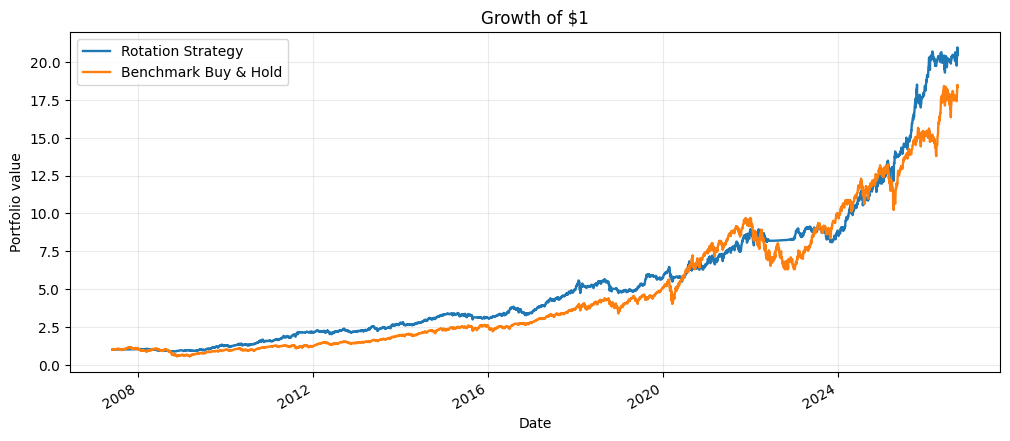

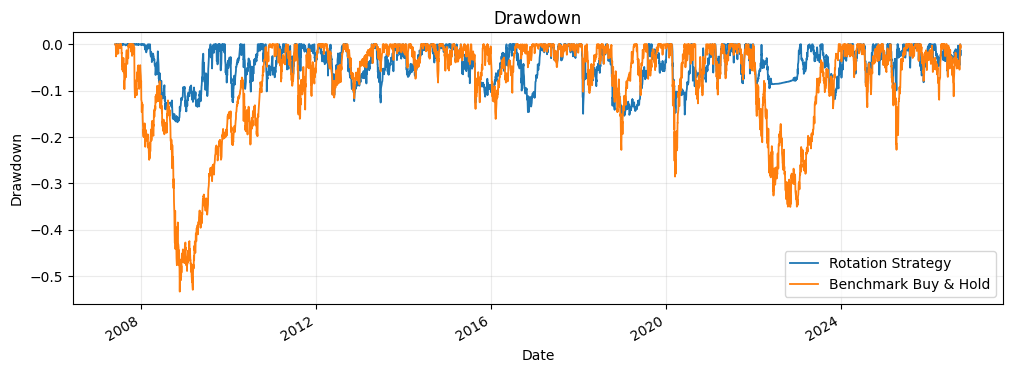

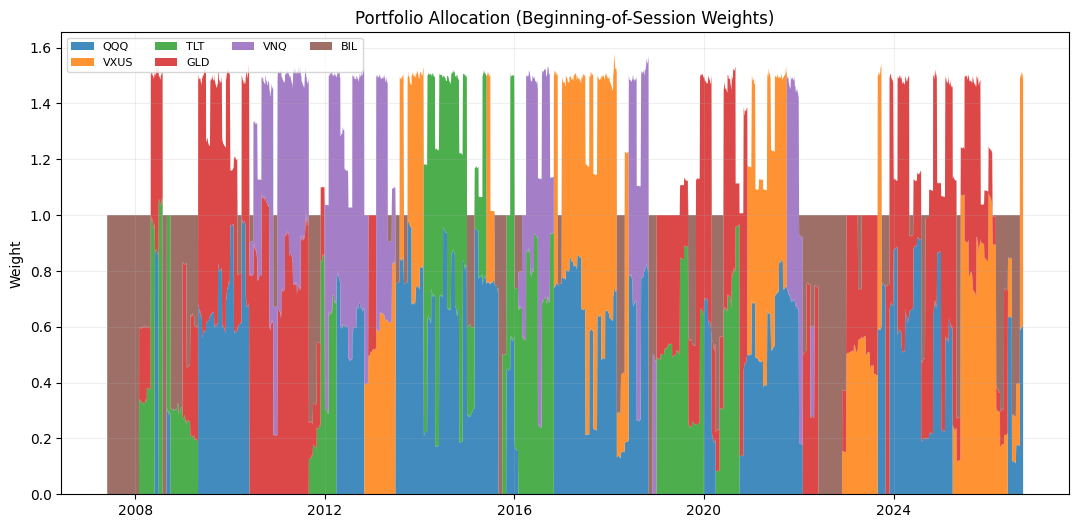

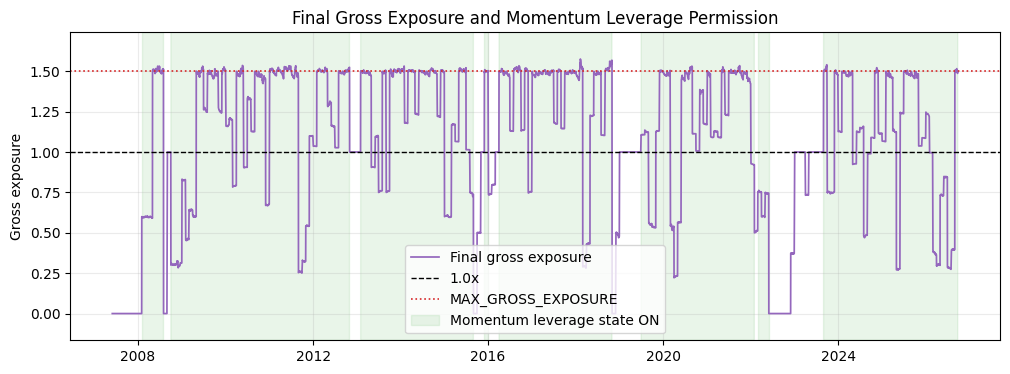

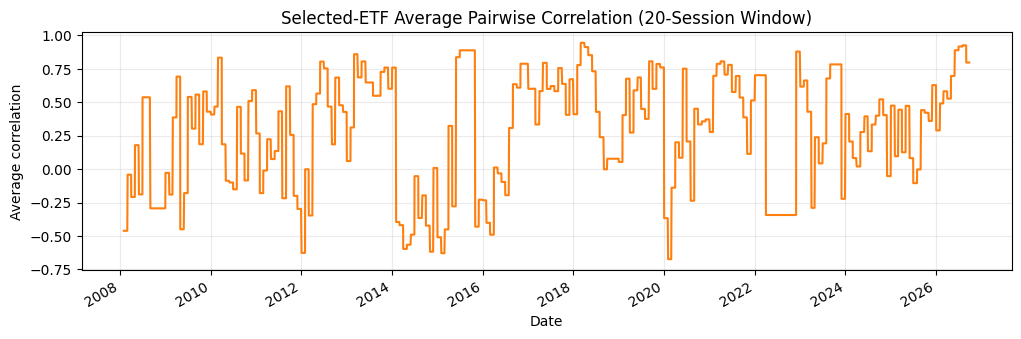

Ten largest strategy drawdowns and leverage context:


,Drawdown Start,Drawdown Trough,Recovery Date,Maximum Drawdown,Leverage >1x at Start,Maximum Exposure During Drawdown,Momentum Leverage State at Start
0,2008-03-18 00:00:00,2008-10-31 00:00:00,2009-08-03 00:00:00,-16.82%,False,1.53x,True
1,2018-08-30 00:00:00,2018-12-24 00:00:00,2019-08-07 00:00:00,-16.21%,True,1.57x,True
2,2020-02-20 00:00:00,2020-06-05 00:00:00,2020-07-27 00:00:00,-15.16%,True,1.51x,True
3,2018-01-29 00:00:00,2018-02-08 00:00:00,2018-08-17 00:00:00,-15.00%,True,1.58x,True
4,2016-08-01 00:00:00,2016-11-04 00:00:00,2017-03-01 00:00:00,-14.63%,True,1.53x,True
5,2015-04-27 00:00:00,2015-08-25 00:00:00,2016-05-09 00:00:00,-12.60%,True,1.52x,True
6,2013-05-22 00:00:00,2013-06-24 00:00:00,2013-10-17 00:00:00,-12.57%,False,1.51x,True
7,2009-12-03 00:00:00,2010-02-08 00:00:00,2010-04-09 00:00:00,-12.51%,True,1.53x,True
8,2012-09-17 00:00:00,2012-11-15 00:00:00,2013-04-10 00:00:00,-12.26%,True,1.52x,True
9,2021-12-31 00:00:00,2022-01-27 00:00:00,2023-01-25 00:00:00,-12.03%,True,1.42x,True


In [70]:
# Equity curves
growth = (1.0 + common_returns).cumprod()
ax = growth.plot(figsize=(12, 5), linewidth=1.7, title="Growth of $1")
ax.set_ylabel("Portfolio value")
ax.grid(alpha=0.25)
plt.show()

# Drawdowns
drawdowns = common_returns.apply(drawdown_series)
ax = drawdowns.plot(figsize=(12, 4), linewidth=1.3, title="Drawdown")
ax.set_ylabel("Drawdown")
ax.grid(alpha=0.25)
plt.show()

# Long-only ETF allocation weights; financing is tracked separately.
plot_weights = full_result["active_weights"].loc[common_returns.index].dropna(how="all")
fig, ax = plt.subplots(figsize=(13, 6))
positive_weights = plot_weights.clip(lower=0)
ax.stackplot(
    positive_weights.index,
    *[positive_weights[column].values for column in positive_weights.columns],
    labels=positive_weights.columns,
    alpha=0.85,
)
ax.set_title("Portfolio Allocation (Beginning-of-Session Weights)")
ax.set_ylabel("Weight")
ax.legend(loc="upper left", ncol=4, fontsize=8)
ax.grid(alpha=0.2)
plt.show()

# Final gross exposure and momentum leverage state.
exposure = full_result["gross_exposure"].loc[common_returns.index]
gate_state = full_result["leverage_state_daily"].reindex(exposure.index).fillna(False)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(exposure.index, exposure.values, color="tab:purple", linewidth=1.25,
        label="Final gross exposure")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="1.0x")
ax.axhline(CONFIG.max_gross_exposure, color="tab:red", linestyle=":", linewidth=1.2,
           label="MAX_GROSS_EXPOSURE")
ax.fill_between(exposure.index, 0, 1, where=gate_state.to_numpy(),
                transform=ax.get_xaxis_transform(), color="tab:green", alpha=0.10,
                label="Momentum leverage state ON")
ax.set_title("Final Gross Exposure and Momentum Leverage Permission")
ax.set_ylabel("Gross exposure")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

# Portfolio average pairwise correlation
ax = full_result["correlation_daily"].loc[common_returns.index].plot(
    figsize=(12, 3.5), title=f"Selected-ETF Average Pairwise Correlation ({CONFIG.vol_lookback}-Session Window)",
    color="tab:orange",
)
ax.set_ylabel("Average correlation")
ax.grid(alpha=0.25)
plt.show()

print("Ten largest strategy drawdowns and leverage context:")
display(largest_drawdowns.style.format({
    "Maximum Drawdown": "{:.2%}",
    "Maximum Exposure During Drawdown": "{:.2f}x",
}))


In [71]:
# Export the rotation strategy equity curve (growth of $1).
EQUITY_CURVE_CSV = "../../portfolio/data/diversified_etf_rotation_equity_curve.csv"

equity_curve_export = (
    (1.0 + common_returns["Rotation Strategy"]).cumprod()
    .rename("Equity")
    .rename_axis("Date")
    .reset_index()
)
equity_curve_export["Date"] = pd.to_datetime(
    equity_curve_export["Date"]
).dt.strftime("%Y-%m-%d")
equity_curve_export.to_csv(EQUITY_CURVE_CSV, index=False)

print(f"Exported {len(equity_curve_export):,} rows to {EQUITY_CURVE_CSV}")
display(equity_curve_export.head())


Exported 4,862 rows to ../../portfolio/data/diversified_etf_rotation_equity_curve.csv


,Date,Equity
0,2007-05-31,1.0000
1,2007-06-01,1.0002
2,2007-06-04,1.0004
3,2007-06-05,1.0004
4,2007-06-06,1.0009


## Correlation diagnostics

Each weekly value is computed from the trailing `VOL_LOOKBACK` daily return matrix of the ETFs actually selected at that signal. Low/high labels use the **prior** expanding median of portfolio average correlation, so the diagnostic classification also avoids a full-sample optimized threshold. Correlation is not a selection input.


In [72]:
def conditional_performance(returns, labels):
    rows = []
    aligned = pd.concat([returns.rename("Return"), labels.rename("Label")], axis=1).dropna()
    for label, group in aligned.groupby("Label"):
        metrics = calculate_metrics(group["Return"], CONFIG.risk_free_rate)
        rows.append({
            "Period": label,
            "Annualized Return": group["Return"].mean() * 252,
            "Annualized Volatility": metrics["Annualized Volatility"],
            "Sharpe": metrics["Sharpe"],
            "Maximum Drawdown": metrics["Maximum Drawdown"],
            "Observations": len(group),
        })
    return pd.DataFrame(rows).set_index("Period") if rows else pd.DataFrame()

portfolio_corr = full_result["correlation_daily"].reindex(common_returns.index)
corr_threshold = portfolio_corr.expanding(min_periods=26).median().shift(1)
corr_label = pd.Series(
    np.where(portfolio_corr <= corr_threshold, "Low Correlation", "High Correlation"),
    index=portfolio_corr.index,
).where(portfolio_corr.notna() & corr_threshold.notna())

correlation_performance = conditional_performance(
    common_returns["Rotation Strategy"], corr_label
)
display(correlation_performance.style.format({
    "Annualized Return": "{:.2%}", "Annualized Volatility": "{:.2%}",
    "Sharpe": "{:.2f}", "Maximum Drawdown": "{:.2%}",
}))

display(full_result["signal_diagnostics"][[
    "Average Pairwise Correlation", "Maximum Pairwise Correlation"
]].tail(12))


,Annualized Return,Annualized Volatility,Sharpe,Maximum Drawdown,Observations
Period,,,,,
High Correlation,17.33%,15.59%,1.11,-24.15%,2754
Low Correlation,17.27%,14.63%,1.18,-18.15%,1912


,Average Pairwise Correlation,Maximum Pairwise Correlation
Date,,
2025-10-31,0.3595,0.3595
2025-11-28,0.6270,0.6270
2025-12-31,0.2886,0.2886
2026-01-30,0.4901,0.4901
2026-02-27,0.5807,0.5807
2026-03-31,0.5261,0.5261
2026-04-30,0.6951,0.6951
2026-05-29,0.8874,0.8874
2026-06-30,0.9150,0.9150


In [73]:
# Calendar-year returns over the exact common strategy/benchmark period.
annual_returns = (1.0 + common_returns).resample("Y").prod() - 1.0
annual_returns.index = annual_returns.index.year
annual_returns.index.name = "Year"
annual_returns = annual_returns.rename(columns={
    "Rotation Strategy": "Strategy Return",
    "Benchmark Buy & Hold": "Benchmark Return",
})
annual_returns["Excess Return"] = (
    annual_returns["Strategy Return"] - annual_returns["Benchmark Return"]
)

beat_years = int((annual_returns["Excess Return"] > 0).sum())
underperformed_years = int((annual_returns["Excess Return"] < 0).sum())
positive_year_pct = float((annual_returns["Strategy Return"] > 0).mean())

display(annual_returns.style.format("{:.2%}"))
print(f"Years strategy beat benchmark: {beat_years}")
print(f"Years strategy underperformed benchmark: {underperformed_years}")
print(f"Positive strategy years: {positive_year_pct:.1%}")


,Strategy Return,Benchmark Return,Excess Return
Year,,,
2007,2.50%,8.79%,-6.29%
2008,-6.99%,-41.73%,34.74%
2009,32.60%,54.68%,-22.09%
2010,26.92%,20.14%,6.78%
2011,34.81%,3.48%,31.33%
2012,2.23%,18.11%,-15.88%
2013,26.28%,36.63%,-10.36%
2014,18.15%,19.18%,-1.03%
2015,-6.77%,9.44%,-16.20%


Years strategy beat benchmark: 9
Years strategy underperformed benchmark: 11
Positive strategy years: 80.0%


## Benchmark regime diagnostics

Regimes use only `BENCHMARK_ETF`. The 20-session volatility threshold is its trailing 252-session median (minimum 126 observations). The completed close-of-session regime label is shifted one session before it is paired with strategy returns. These labels are diagnostic and never feed the portfolio.


In [74]:
def calculate_regimes(prices, benchmark, trend_ma=200):
    benchmark_price = prices[benchmark]
    benchmark_return = benchmark_price.pct_change(fill_method=None)
    benchmark_ma = benchmark_price.rolling(trend_ma, min_periods=trend_ma).mean()
    vol20 = benchmark_return.rolling(20, min_periods=20).std() * np.sqrt(252)
    trailing_threshold = vol20.rolling(252, min_periods=126).median()

    trend = pd.Series(
        np.where(benchmark_price > benchmark_ma, "Bull", "Bear"),
        index=prices.index,
    ).where(benchmark_ma.notna())
    volatility = pd.Series(
        np.where(vol20 > trailing_threshold, "High Vol", "Low Vol"),
        index=prices.index,
    ).where(vol20.notna() & trailing_threshold.notna())

    # A return on day t is labeled only with the regime known after day t-1's close.
    regime = (trend + " / " + volatility).shift(1)
    return pd.DataFrame({
        "Benchmark MA": benchmark_ma,
        "Benchmark 20D Vol": vol20,
        "Trailing Vol Median": trailing_threshold,
        "Regime": regime,
    })


def regime_performance(strategy_returns, regime_data, risk_free_rate):
    aligned = pd.concat(
        [strategy_returns.rename("Return"), regime_data["Regime"]], axis=1
    ).dropna()
    rows = []
    expected = [
        "Bull / Low Vol", "Bull / High Vol",
        "Bear / Low Vol", "Bear / High Vol",
    ]
    for regime in expected:
        values = aligned.loc[aligned["Regime"].eq(regime), "Return"]
        metrics = calculate_metrics(values, risk_free_rate)
        rows.append({
            "Regime": regime,
            "Annualized Return": values.mean() * 252 if len(values) else np.nan,
            "Volatility": metrics["Annualized Volatility"],
            "Sharpe": metrics["Sharpe"],
            "Maximum Drawdown": metrics["Maximum Drawdown"],
            "Observations": len(values),
        })
    return pd.DataFrame(rows).set_index("Regime")

regime_data = calculate_regimes(prices, CONFIG.benchmark, trend_ma=200)
regime_table = regime_performance(
    common_returns["Rotation Strategy"], regime_data, CONFIG.risk_free_rate
)
display(regime_table.style.format({
    "Annualized Return": "{:.2%}", "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}", "Maximum Drawdown": "{:.2%}",
}))


,Annualized Return,Volatility,Sharpe,Maximum Drawdown,Observations
Regime,,,,,
Bull / Low Vol,14.01%,16.07%,0.87,-22.07%,2213
Bull / High Vol,20.40%,14.48%,1.41,-15.34%,1624
Bear / Low Vol,37.36%,9.91%,3.77,-3.79%,134
Bear / High Vol,15.37%,13.94%,1.10,-10.33%,793


## Primary experiment: leverage policy ablation

All non-leverage inputs remain identical. The three versions compare no leverage, unconditional volatility-target leverage, and momentum-gated volatility-target leverage. No parameter is optimized.


,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Worst Month,Worst Year,Average Gross Exposure,Maximum Gross Exposure,% Time > 1x,Annual Turnover,Transaction Costs
Strategy,,,,,,,,,,,,,
No Leverage,12.64%,10.70%,1.17,1.66,-12.60%,1.00,-6.57%,-5.44%,77.62%,100.00%,0.00%,304.40%,2.94%
Unconditional VT Leverage,17.47%,15.27%,1.13,1.60,-18.79%,0.93,-9.02%,-9.17%,111.48%,157.62%,70.59%,484.44%,4.67%
Momentum-Gated VT Leverage,17.00%,14.90%,1.13,1.60,-16.82%,1.01,-9.02%,-7.04%,106.66%,157.62%,61.23%,473.73%,4.57%


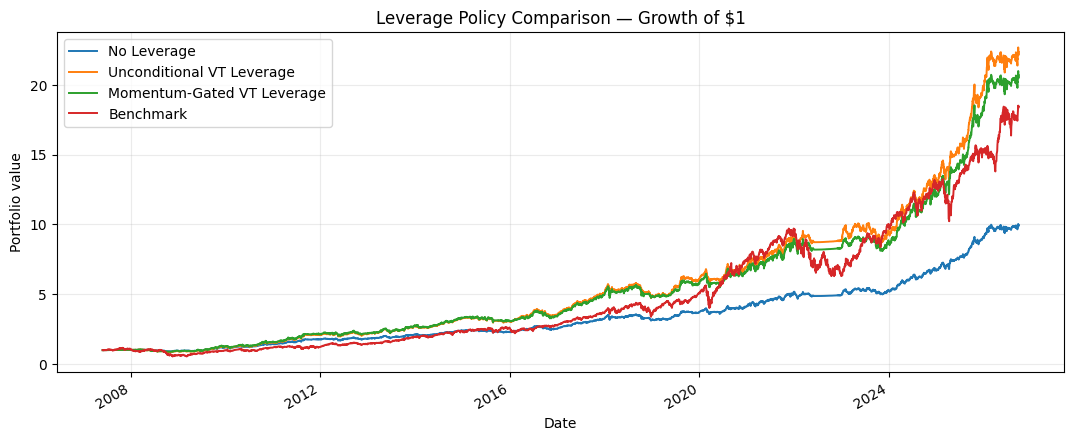

In [ ]:
def _worst_compounded_period(returns, frequency):
    values = (1.0 + returns).resample(frequency).prod() - 1.0
    return float(values.min()) if len(values) else np.nan


def run_leverage_policy_experiment(prices, base_cfg):
    configured_max = base_cfg.max_gross_exposure
    configs = {
        "No Leverage": replace(base_cfg, max_gross_exposure=1.0,
                               use_momentum_leverage_gate=False),
        "Unconditional VT Leverage": replace(base_cfg, max_gross_exposure=configured_max,
                                             use_momentum_leverage_gate=False),
        "Momentum-Gated VT Leverage": replace(base_cfg, max_gross_exposure=configured_max,
                                              use_momentum_leverage_gate=True),
    }
    results = {name: run_backtest(prices, cfg) for name, cfg in configs.items()}
    benchmark = prices[base_cfg.benchmark].pct_change(fill_method=None).rename("Benchmark")
    aligned = pd.concat(
        {name: result["returns"] for name, result in results.items()} | {"Benchmark": benchmark},
        axis=1,
    ).dropna()
    rows = []
    for name, result in results.items():
        returns = aligned[name]
        metrics = calculate_metrics(returns, base_cfg.risk_free_rate)
        exposure = result["gross_exposure"].reindex(aligned.index)
        years = len(returns) / 252.0
        rows.append({
            "Strategy": name, "CAGR": metrics["CAGR"],
            "Annualized Volatility": metrics["Annualized Volatility"],
            "Sharpe": metrics["Sharpe"], "Sortino": metrics["Sortino"],
            "Max Drawdown": metrics["Maximum Drawdown"], "Calmar": metrics["Calmar"],
            "Worst Month": _worst_compounded_period(returns, "M"),
            "Worst Year": _worst_compounded_period(returns, "Y"),
            "Average Gross Exposure": exposure.mean(),
            "Maximum Gross Exposure": exposure.max(),
            "% Time > 1x": exposure.gt(1.0 + 1e-6).mean(),
            "Annual Turnover": result["turnover"].reindex(aligned.index).sum() / years,
            "Transaction Costs": result["costs"].reindex(aligned.index).sum(),
        })
    return results, pd.DataFrame(rows).set_index("Strategy"), aligned


leverage_results, leverage_ablation_table, leverage_comparison_returns = (
    run_leverage_policy_experiment(prices, CONFIG)
)
display(leverage_ablation_table.style.format({
    "CAGR": "{:.2%}", "Annualized Volatility": "{:.2%}", "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}", "Max Drawdown": "{:.2%}", "Calmar": "{:.2f}",
    "Worst Month": "{:.2%}", "Worst Year": "{:.2%}",
    "Average Gross Exposure": "{:.2%}", "Maximum Gross Exposure": "{:.2%}",
    "% Time > 1x": "{:.2%}", "Annual Turnover": "{:.2%}",
    "Transaction Costs": "{:.2%}",
}))

ax = ((1.0 + leverage_comparison_returns).cumprod()).plot(
    figsize=(13, 5), linewidth=1.4, title="Leverage Policy Comparison — Growth of $1")
ax.set_ylabel("Portfolio value"); ax.grid(alpha=0.25); plt.show()
strategy_columns = ["No Leverage", "Unconditional VT Leverage", "Momentum-Gated VT Leverage"]
ax = leverage_comparison_returns[strategy_columns].apply(drawdown_series).plot(
    figsize=(13, 4.5), linewidth=1.25, title="Leverage Policy Comparison — Drawdowns")
ax.set_ylabel("Drawdown"); ax.grid(alpha=0.25); plt.show()


## Leverage contribution and incremental trade-off

Daily log returns are partitioned by whether actual beginning-of-session risky exposure exceeded 1.0x. The attribution is descriptive, not causal.


In [ ]:
gated_result = leverage_results["Momentum-Gated VT Leverage"]
comparison_index = leverage_comparison_returns.index
gated_returns = leverage_comparison_returns["Momentum-Gated VT Leverage"]
gated_exposure = gated_result["gross_exposure"].reindex(comparison_index)
leveraged_mask = gated_exposure.gt(1.0 + 1e-6)
log_returns = np.log1p(gated_returns)

leverage_contribution = pd.Series({
    "Total Strategy Return": np.expm1(log_returns.sum()),
    "Return Attributable to Exposure <= 1x": np.expm1(log_returns[~leveraged_mask].sum()),
    "Return Attributable to Exposure > 1x": np.expm1(log_returns[leveraged_mask].sum()),
    "Sessions at Exposure > 1x": int(leveraged_mask.sum()),
})
display(leverage_contribution.to_frame("Value"))
no_leverage = leverage_ablation_table.loc["No Leverage"]
gated = leverage_ablation_table.loc["Momentum-Gated VT Leverage"]
incremental_tradeoff = pd.Series({
    "CAGR Difference vs No Leverage": gated["CAGR"] - no_leverage["CAGR"],
    "MaxDD Difference vs No Leverage": gated["Max Drawdown"] - no_leverage["Max Drawdown"],
    "Sharpe Difference vs No Leverage": gated["Sharpe"] - no_leverage["Sharpe"],
})
display(incremental_tradeoff.to_frame("Difference"))
print("Parameter robustness is intentionally deferred; no leverage parameters are optimized.")


In [ ]:
no_lev = leverage_ablation_table.loc["No Leverage"]
unconditional = leverage_ablation_table.loc["Unconditional VT Leverage"]
gated = leverage_ablation_table.loc["Momentum-Gated VT Leverage"]

print("FINAL LEVERAGE POLICY COMPARISON")
print("\nNO LEVERAGE")
print(f"CAGR:   {no_lev['CAGR']:.2%}")
print(f"Sharpe: {no_lev['Sharpe']:.2f}")
print(f"MaxDD:  {no_lev['Max Drawdown']:.2%}")
print("\nUNCONDITIONAL LEVERAGE")
print(f"CAGR:   {unconditional['CAGR']:.2%}")
print(f"Sharpe: {unconditional['Sharpe']:.2f}")
print(f"MaxDD:  {unconditional['Max Drawdown']:.2%}")
print(f"% time leveraged: {unconditional['% Time > 1x']:.2%}")
print("\nMOMENTUM-GATED LEVERAGE")
print(f"CAGR:   {gated['CAGR']:.2%}")
print(f"Sharpe: {gated['Sharpe']:.2f}")
print(f"MaxDD:  {gated['Max Drawdown']:.2%}")
print(f"% time leveraged: {gated['% Time > 1x']:.2%}")
print("\nINCREMENTAL GATED-LEVERAGE TRADE-OFF VS NO LEVERAGE")
print(f"Incremental CAGR:  {gated['CAGR'] - no_lev['CAGR']:+.2%}")
print(f"Incremental MaxDD: {gated['Max Drawdown'] - no_lev['Max Drawdown']:+.2%}")
print(f"Sharpe change:     {gated['Sharpe'] - no_lev['Sharpe']:+.2f}")
print("\nHigher CAGR alone is not evidence of a superior policy.")
print("Diagnostic research only; this notebook does not make a trading recommendation.")
